# XGBoost - SMARD data

In this notebook, we develop an xgboost model to predict negative day ahead price based on only SMARD data, which provides us historical information regarding the energy produced by various sources, energy consumed and day ahead price.

In [77]:
import pandas as pd
import numpy as np
import seaborn as sns
import matplotlib.pyplot as plt

In [78]:
import xgboost
from xgboost import XGBClassifier
from sklearn.metrics import roc_auc_score, roc_curve, f1_score, confusion_matrix, classification_report, recall_score, precision_recall_curve

In [ ]:
df = pd.read_csv("Combined_smard_data.csv")
df['Start_date'] = pd.to_datetime(df['Start_date'])
df = df.set_index('Start_date').sort_index()
df.info()

For modeling, we will create lagged features. We build three lags 24 hrs, 48 hrs, 168 hrs. We are assuming that when we are making the prediction for time t, we will have data for various features upto time (t - 24)

In [83]:
df['Hour'] = df.index.hour
df['Day_of_week'] = df.index.day_of_week
df['Month'] = df.index.month

In [84]:
df['Lag_24']  = df['Negative_price'].shift(24)   # Target variable at the same hour yesterday
df['Lag_48']  = df['Negative_price'].shift(48)   # Target variable at the same hour 2 days ago
df['Lag_168'] = df['Negative_price'].shift(168)  # Target variable at the same hour 1 week ago

Nuclear column has several NaN values. We fill those with 0 and create an additional column 'Nuclear_gap' to keep track of the NaN values

In [85]:
df['Nuclear_gap'] = df['Nuclear'].isna().astype(int)
df['Nuclear'] = df['Nuclear'].fillna(0)

In [86]:
df.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 61374 entries, 2019-05-01 00:00:00 to 2026-05-01 05:00:00
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Biomass            61374 non-null  float64
 1   Hydro              61374 non-null  float64
 2   Wind_offshore      61374 non-null  float64
 3   Wind_onshore       61374 non-null  float64
 4   Photovolt          61374 non-null  float64
 5   Other_ren          61374 non-null  float64
 6   Nuclear            61374 non-null  float64
 7   Lignite            61374 non-null  float64
 8   Hard_coal          61374 non-null  float64
 9   Fossil_gas         61374 non-null  float64
 10  Hydro_pump_stor    61374 non-null  float64
 11  Other_conv         61374 non-null  float64
 12  Renewables_tot     61374 non-null  float64
 13  Renewables_frac    61374 non-null  float64
 14  Solar_frac         61374 non-null  float64
 15  Wind_onshore_frac  61374 non-null  float64
 16

In [87]:
df['Nuclear_gap'].describe()

count    61374.000000
mean         0.321325
std          0.466989
min          0.000000
25%          0.000000
50%          0.000000
75%          1.000000
max          1.000000
Name: Nuclear_gap, dtype: float64

In [88]:
df_clean = df.dropna()

In [89]:
df_clean.info()

<class 'pandas.DataFrame'>
DatetimeIndex: 61206 entries, 2019-05-08 00:00:00 to 2026-05-01 05:00:00
Data columns (total 28 columns):
 #   Column             Non-Null Count  Dtype  
---  ------             --------------  -----  
 0   Biomass            61206 non-null  float64
 1   Hydro              61206 non-null  float64
 2   Wind_offshore      61206 non-null  float64
 3   Wind_onshore       61206 non-null  float64
 4   Photovolt          61206 non-null  float64
 5   Other_ren          61206 non-null  float64
 6   Nuclear            61206 non-null  float64
 7   Lignite            61206 non-null  float64
 8   Hard_coal          61206 non-null  float64
 9   Fossil_gas         61206 non-null  float64
 10  Hydro_pump_stor    61206 non-null  float64
 11  Other_conv         61206 non-null  float64
 12  Renewables_tot     61206 non-null  float64
 13  Renewables_frac    61206 non-null  float64
 14  Solar_frac         61206 non-null  float64
 15  Wind_onshore_frac  61206 non-null  float64
 16

In [90]:
df_clean.columns

Index(['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal', 'Fossil_gas',
       'Hydro_pump_stor', 'Other_conv', 'Renewables_tot', 'Renewables_frac',
       'Solar_frac', 'Wind_onshore_frac', 'Hydro_frac', 'Total_gen',
       'Residuals', 'Price', 'Negative_price', 'Hour', 'Day_of_week', 'Month',
       'Lag_24', 'Lag_48', 'Lag_168', 'Nuclear_gap'],
      dtype='str')

For features, we drop  'Solar_frac', 'Wind_onshore_frac', 'Hydro_frac', 'Renewables_tot', 'Renewables_frac' , 'Price'

In [91]:
features = ['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal', 'Fossil_gas',
       'Hydro_pump_stor', 'Other_conv', 'Total_gen',
       'Residuals','Hour', 'Day_of_week', 'Month',
       'Lag_24', 'Lag_48', 'Lag_168','Nuclear_gap']
X = df_clean[features]
y = df_clean['Negative_price']

In [92]:
valid_start = '2023-10-01'
test_start  = '2024-10-01'

We now perform a train-validation-test split (approximately 60-20-20 percent)

In [93]:
# train-test split

X_train, X_valid = X.loc[X.index < valid_start] , X.loc[(X.index>=valid_start) &  (X.index < test_start )]
y_train, y_valid = y.loc[y.index < valid_start] , y.loc[(y.index>=valid_start) &  (y.index < test_start )]


# Hold-out set
X_test = X.loc[X.index >= test_start]
y_test = y.loc[y.index >= test_start]

In [94]:
from collections import Counter

In [95]:
counter  = Counter(y_train)
estimate = counter[0]/counter[1]
print(f"estimate:{estimate}")

estimate:47.45226130653266


In [96]:
model = XGBClassifier(objective= 'binary:logistic',val_metric='aucpr',n_estimators=300,
                      max_depth=6, learning_rate=0.05,scale_pos_weight=estimate,random_state=42 )

In [97]:
X_train.select_dtypes(exclude=['number']).columns

Index([], dtype='str')

In [98]:
model.fit(X_train,y_train)

/Users/ranadeeproy/Desktop/erdos_ds_environment_2026/lib/python3.12/site-packages/xgboost/core.py:158: UserWarning: [09:54:45] WARNING: /Users/runner/miniforge3/conda-bld/xgboost-split_1744329043786/work/src/learner.cc:740: 
Parameters: { "val_metric" } are not used.

  warnings.warn(smsg, UserWarning)


,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,None


In [99]:
y_prob = model.predict_proba(X_valid)[:,1]


In [100]:
ROC_AUC_score = roc_auc_score(y_valid,y_prob)
print(f"ROC-AUC score:{ROC_AUC_score}")

ROC-AUC score:0.9740875767892317


In [101]:
y_pred = (y_prob>=0.5).astype(int)
print(classification_report(y_valid,y_pred))

              precision    recall  f1-score   support

           0       0.98      0.97      0.98      8258
           1       0.62      0.72      0.66       526

    accuracy                           0.96      8784
   macro avg       0.80      0.85      0.82      8784
weighted avg       0.96      0.96      0.96      8784



In [102]:
from sklearn.metrics import RocCurveDisplay, average_precision_score

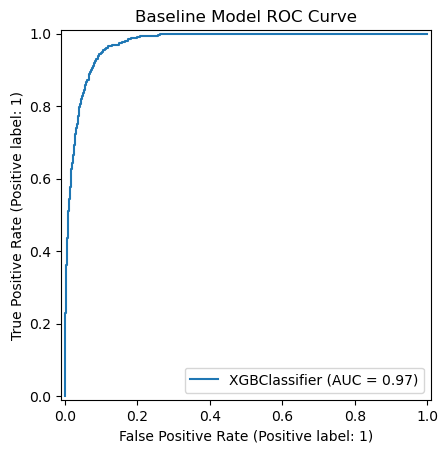

In [103]:
RocCurveDisplay.from_estimator(model, X_valid, y_valid)
plt.title("Baseline Model ROC Curve")
plt.show()

In [104]:
pr_auc = average_precision_score(y_valid,y_prob)
print(pr_auc)

0.7381541138474746


In [105]:
baseline = y_valid.mean()
print(baseline)

0.0598816029143898


In [106]:
precisions, recalls, thresholds = precision_recall_curve(y_valid, y_prob)

Text(0.5, 1.0, 'Precision-Recall Curve')

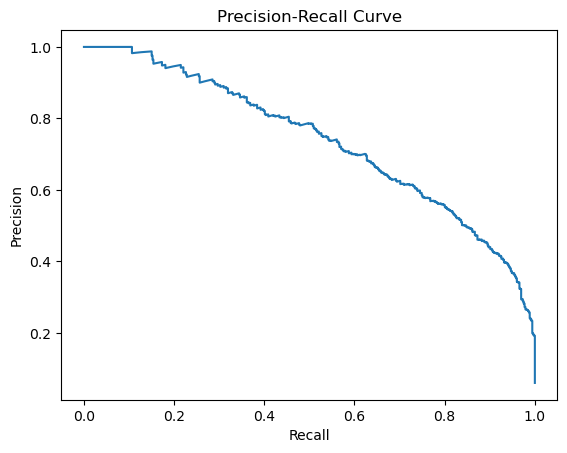

In [107]:
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")


In [108]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model,X_valid,y_valid,n_repeats=10,random_state=42,scoring="average_precision"  )

perm_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

perm_importance = perm_importance.sort_values(
    by="importance_mean",
    ascending=False
)

print(perm_importance.head(28))

            feature  importance_mean  importance_std
13        Residuals         0.521384        0.011521
7           Lignite         0.255096        0.010550
2     Wind_offshore         0.146004        0.011223
8         Hard_coal         0.093557        0.006213
9        Fossil_gas         0.084683        0.007782
1             Hydro         0.019166        0.008365
10  Hydro_pump_stor         0.018849        0.002545
14             Hour         0.018597        0.003476
0           Biomass         0.016431        0.003499
15      Day_of_week         0.013588        0.002375
17           Lag_24         0.007564        0.002431
16            Month         0.005889        0.002818
11       Other_conv         0.003697        0.000941
12        Total_gen         0.003409        0.001430
19          Lag_168         0.000094        0.000438
6           Nuclear         0.000000        0.000000
20      Nuclear_gap         0.000000        0.000000
18           Lag_48        -0.000583        0.

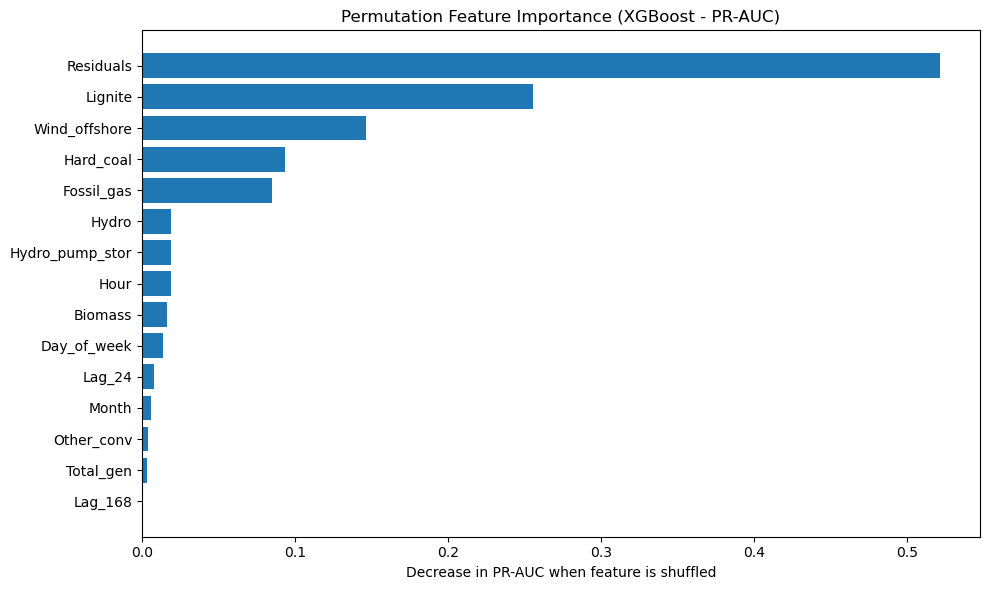

In [109]:
top_n = 15
top_features = perm_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(10,6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Decrease in PR-AUC when feature is shuffled")
plt.title("Permutation Feature Importance (XGBoost - PR-AUC)")
plt.tight_layout()
plt.show()

In [110]:
df.columns

Index(['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal', 'Fossil_gas',
       'Hydro_pump_stor', 'Other_conv', 'Renewables_tot', 'Renewables_frac',
       'Solar_frac', 'Wind_onshore_frac', 'Hydro_frac', 'Total_gen',
       'Residuals', 'Price', 'Negative_price', 'Hour', 'Day_of_week', 'Month',
       'Lag_24', 'Lag_48', 'Lag_168', 'Nuclear_gap'],
      dtype='str')

In [111]:
df_forecast = df.copy()
df_forecast['Target'] = df_forecast['Negative_price'].shift(-24)


df_forecast['Price_lag_24']  = df_forecast['Price'].shift(24)          #  Day ahead price at the same hour yesterday
df_forecast['Price_lag_48']  = df_forecast['Price'].shift(48)         # Day ahead price at the same hour 2 days ago
df_forecast['Price_lag_168'] = df_forecast['Price'].shift(168)        # Day ahead price at the same hour 1 week ago

rolling_vars = ['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal', 'Fossil_gas',
       'Hydro_pump_stor', 'Other_conv','Price']


gen_cons = ['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal', 'Fossil_gas',
       'Hydro_pump_stor', 'Other_conv','Residuals', 'Nuclear_gap']

for c in gen_cons:
    df_forecast[c+'_lag_24'] = df_forecast[c].shift(24)

for c in rolling_vars:
    df_forecast[c+'_rolling_mean'] =df_forecast[c].rolling(24).mean()

In [112]:
df_forecast.columns

Index(['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal', 'Fossil_gas',
       'Hydro_pump_stor', 'Other_conv', 'Renewables_tot', 'Renewables_frac',
       'Solar_frac', 'Wind_onshore_frac', 'Hydro_frac', 'Total_gen',
       'Residuals', 'Price', 'Negative_price', 'Hour', 'Day_of_week', 'Month',
       'Lag_24', 'Lag_48', 'Lag_168', 'Nuclear_gap', 'Target', 'Price_lag_24',
       'Price_lag_48', 'Price_lag_168', 'Biomass_lag_24', 'Hydro_lag_24',
       'Wind_offshore_lag_24', 'Wind_onshore_lag_24', 'Photovolt_lag_24',
       'Other_ren_lag_24', 'Nuclear_lag_24', 'Lignite_lag_24',
       'Hard_coal_lag_24', 'Fossil_gas_lag_24', 'Hydro_pump_stor_lag_24',
       'Other_conv_lag_24', 'Residuals_lag_24', 'Nuclear_gap_lag_24',
       'Biomass_rolling_mean', 'Hydro_rolling_mean',
       'Wind_offshore_rolling_mean', 'Wind_onshore_rolling_mean',
       'Photovolt_rolling_mean', 'Other_ren_rolling_mean',
       'Nuclear_rolli

In [113]:
feature_cols = ['Hour', 'Day_of_week', 'Month', 'Biomass_lag_24', 'Hydro_lag_24','Lag_24', 'Lag_48', 'Lag_168',
       'Wind_offshore_lag_24', 'Wind_onshore_lag_24', 'Photovolt_lag_24',
       'Other_ren_lag_24', 'Nuclear_lag_24', 'Lignite_lag_24',
       'Hard_coal_lag_24', 'Fossil_gas_lag_24', 'Hydro_pump_stor_lag_24',
       'Other_conv_lag_24', 'Residuals_lag_24', 'Nuclear_gap_lag_24','Price_rolling_mean']

In [114]:
df_forecast[feature_cols].info()

<class 'pandas.DataFrame'>
DatetimeIndex: 61374 entries, 2019-05-01 00:00:00 to 2026-05-01 05:00:00
Data columns (total 21 columns):
 #   Column                  Non-Null Count  Dtype  
---  ------                  --------------  -----  
 0   Hour                    61374 non-null  int32  
 1   Day_of_week             61374 non-null  int32  
 2   Month                   61374 non-null  int32  
 3   Biomass_lag_24          61350 non-null  float64
 4   Hydro_lag_24            61350 non-null  float64
 5   Lag_24                  61350 non-null  float64
 6   Lag_48                  61326 non-null  float64
 7   Lag_168                 61206 non-null  float64
 8   Wind_offshore_lag_24    61350 non-null  float64
 9   Wind_onshore_lag_24     61350 non-null  float64
 10  Photovolt_lag_24        61350 non-null  float64
 11  Other_ren_lag_24        61350 non-null  float64
 12  Nuclear_lag_24          61350 non-null  float64
 13  Lignite_lag_24          61350 non-null  float64
 14  Hard_coal_lag_

In [115]:
df_forecast = df_forecast.dropna()

In [116]:
X= df_forecast[feature_cols]
y = df_forecast['Target']


In [117]:
X.shape, y.shape

((61182, 21), (61182,))

In [118]:
# train-test split

X_train, X_valid = X.loc[X.index < valid_start] , X.loc[(X.index>=valid_start) &  (X.index < test_start )]
y_train, y_valid = y.loc[y.index < valid_start] , y.loc[(y.index>=valid_start) &  (y.index < test_start )]


# Hold-out set
X_test = X.loc[X.index >= test_start]
y_test = y.loc[y.index >= test_start]

In [119]:
counter  = Counter(y_train)
estimate = counter[0]/counter[1]
print(f"estimate:{estimate}")

estimate:47.270337922403


In [120]:
model = XGBClassifier(objective= 'binary:logistic',eval_metric='logloss',n_estimators=300,
                      max_depth=6, learning_rate=0.05,scale_pos_weight=estimate,random_state=42 )

In [121]:
model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [122]:
y_prob = model.predict_proba(X_valid)[:,1]

In [123]:
baseline = y_valid.mean()
print(baseline)

0.05954007285974499


In [124]:
pr_auc = average_precision_score(y_valid, y_prob)

print("Average precision score:",pr_auc)

Average precision score: 0.27122899784343535


In [125]:
precisions, recalls, thresholds = precision_recall_curve(y_valid, y_prob)

Text(0.5, 1.0, 'Precision-Recall Curve')

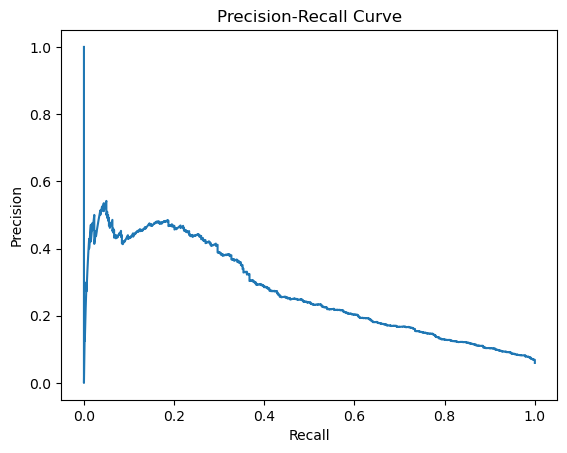

In [126]:
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")


We observe that there is a sharp dip near 0.0 in the precision recall curve. This indicates that there maybe a lot of noise

Best f1 score: 0.3533980582024392 at threshold: 0.3874211609363556 


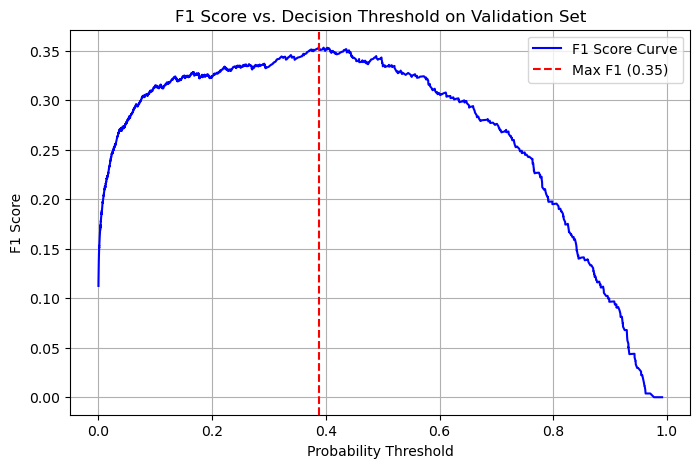

In [127]:
f1_scores = 2*(precisions)*(recalls)/(precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 1.0
best_f1_score = f1_scores[best_idx]

print(f"Best f1 score: {best_f1_score} at threshold: {best_threshold} ")



plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score Curve', color='blue')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Max F1 ({best_f1_score:.2f})')
plt.xlabel('Probability Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Decision Threshold on Validation Set')
plt.legend()
plt.grid(True)
plt.show()

In [128]:
df_forecast[['Target']].isna().sum()

Target    0
dtype: int64

In [129]:
ROC_AUC_score = roc_auc_score(y_valid,y_prob)
print(f"ROC-AUC score:{ROC_AUC_score}")

ROC-AUC score:0.8216915947055239


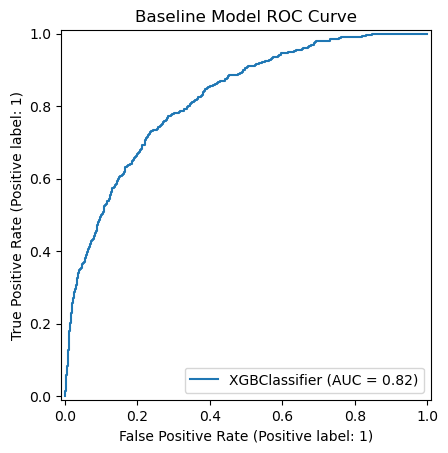

In [130]:
RocCurveDisplay.from_estimator(model, X_valid, y_valid)
plt.title("Baseline Model ROC Curve")
plt.show()

In [131]:
pd.Series(y_prob).describe()

count    8784.000000
mean        0.068841
std         0.164455
min         0.000005
25%         0.000940
50%         0.006139
75%         0.040222
max         0.991438
dtype: float64

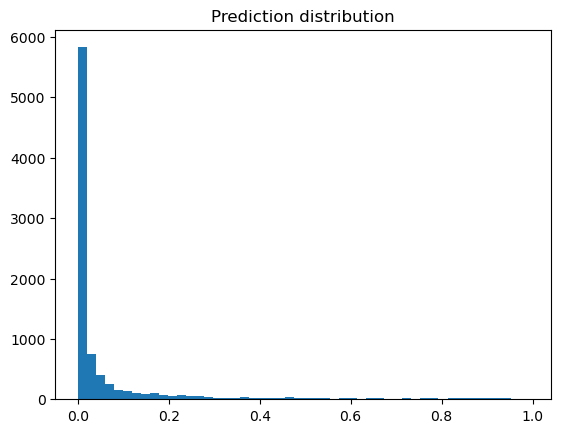

In [132]:
plt.hist(y_prob, bins=50)
plt.title("Prediction distribution")
plt.show()

In [133]:
from sklearn.inspection import permutation_importance

result = permutation_importance(model,X_valid,y_valid,n_repeats=10,random_state=42,scoring="average_precision"  )

perm_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

perm_importance = perm_importance.sort_values(
    by="importance_mean",
    ascending=False
)

print(perm_importance.head(28))

                   feature  importance_mean  importance_std
1              Day_of_week         0.119305        0.004463
0                     Hour         0.101312        0.008711
10        Photovolt_lag_24         0.070105        0.007727
20      Price_rolling_mean         0.024939        0.010046
2                    Month         0.022498        0.005449
15       Fossil_gas_lag_24         0.021458        0.005042
3           Biomass_lag_24         0.009745        0.004325
8     Wind_offshore_lag_24         0.009249        0.003607
13          Lignite_lag_24         0.006588        0.007574
17       Other_conv_lag_24         0.005130        0.003895
4             Hydro_lag_24         0.002895        0.001541
16  Hydro_pump_stor_lag_24         0.002711        0.001358
11        Other_ren_lag_24         0.001479        0.008794
19      Nuclear_gap_lag_24         0.000000        0.000000
12          Nuclear_lag_24         0.000000        0.000000
6                   Lag_48        -0.000

We note that several features have negative importance mean, suggesting that they might be responsible for the unexpected sudden drop seen in the precision recall curve. Hence, going forward we will drop these features

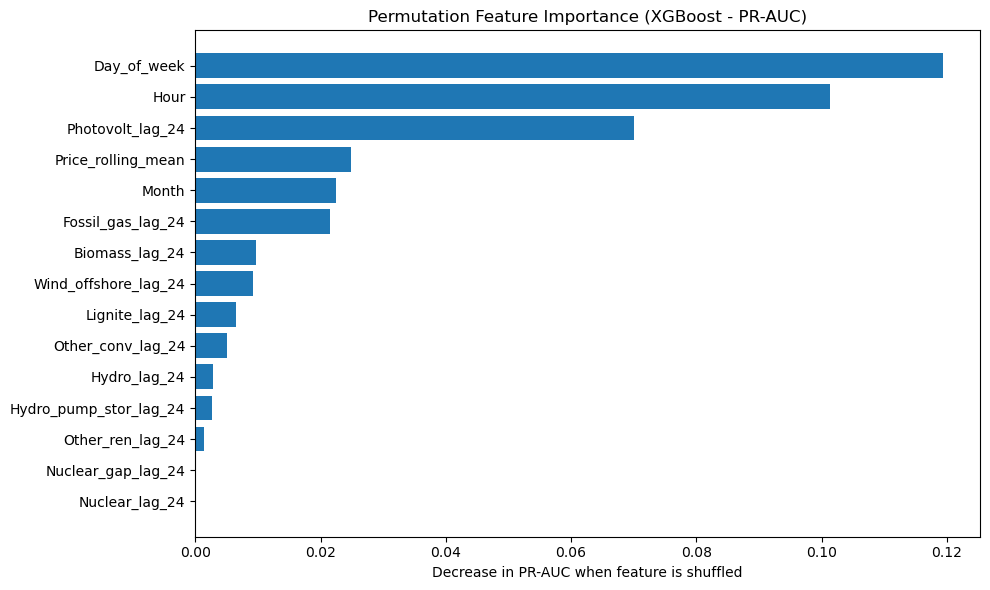

In [134]:
top_n = 15
top_features = perm_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(10,6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Decrease in PR-AUC when feature is shuffled")
plt.title("Permutation Feature Importance (XGBoost - PR-AUC)")
plt.tight_layout()
plt.show()

In [135]:
df_final =df_forecast.copy()

In [136]:
df_final.columns


Index(['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal', 'Fossil_gas',
       'Hydro_pump_stor', 'Other_conv', 'Renewables_tot', 'Renewables_frac',
       'Solar_frac', 'Wind_onshore_frac', 'Hydro_frac', 'Total_gen',
       'Residuals', 'Price', 'Negative_price', 'Hour', 'Day_of_week', 'Month',
       'Lag_24', 'Lag_48', 'Lag_168', 'Nuclear_gap', 'Target', 'Price_lag_24',
       'Price_lag_48', 'Price_lag_168', 'Biomass_lag_24', 'Hydro_lag_24',
       'Wind_offshore_lag_24', 'Wind_onshore_lag_24', 'Photovolt_lag_24',
       'Other_ren_lag_24', 'Nuclear_lag_24', 'Lignite_lag_24',
       'Hard_coal_lag_24', 'Fossil_gas_lag_24', 'Hydro_pump_stor_lag_24',
       'Other_conv_lag_24', 'Residuals_lag_24', 'Nuclear_gap_lag_24',
       'Biomass_rolling_mean', 'Hydro_rolling_mean',
       'Wind_offshore_rolling_mean', 'Wind_onshore_rolling_mean',
       'Photovolt_rolling_mean', 'Other_ren_rolling_mean',
       'Nuclear_rolli

In [ ]:
# Dropping columns which had 0 or negative importance mean
cols_to_drop = ['Nuclear_gap_lag_24','Nuclear_lag_24','Lag_48','Wind_onshore_lag_24',
                'Lag_24','Lag_168','Hard_coal_lag_24','Residuals_lag_24']

In [138]:
df_final = df_final.drop(columns=cols_to_drop)

In [139]:
df_final.columns

Index(['Biomass', 'Hydro', 'Wind_offshore', 'Wind_onshore', 'Photovolt',
       'Other_ren', 'Nuclear', 'Lignite', 'Hard_coal', 'Fossil_gas',
       'Hydro_pump_stor', 'Other_conv', 'Renewables_tot', 'Renewables_frac',
       'Solar_frac', 'Wind_onshore_frac', 'Hydro_frac', 'Total_gen',
       'Residuals', 'Price', 'Negative_price', 'Hour', 'Day_of_week', 'Month',
       'Nuclear_gap', 'Target', 'Price_lag_24', 'Price_lag_48',
       'Price_lag_168', 'Biomass_lag_24', 'Hydro_lag_24',
       'Wind_offshore_lag_24', 'Photovolt_lag_24', 'Other_ren_lag_24',
       'Lignite_lag_24', 'Fossil_gas_lag_24', 'Hydro_pump_stor_lag_24',
       'Other_conv_lag_24', 'Biomass_rolling_mean', 'Hydro_rolling_mean',
       'Wind_offshore_rolling_mean', 'Wind_onshore_rolling_mean',
       'Photovolt_rolling_mean', 'Other_ren_rolling_mean',
       'Nuclear_rolling_mean', 'Lignite_rolling_mean',
       'Hard_coal_rolling_mean', 'Fossil_gas_rolling_mean',
       'Hydro_pump_stor_rolling_mean', 'Other_conv_rol

In [140]:
features_final = ['Hour', 'Day_of_week', 'Month', 'Biomass_lag_24', 'Hydro_lag_24',
       'Wind_offshore_lag_24', 'Photovolt_lag_24', 'Lignite_lag_24' ,'Fossil_gas_lag_24', 'Hydro_pump_stor_lag_24',
       'Other_conv_lag_24', 'Price_rolling_mean','Other_ren_lag_24']

In [141]:
X = df_final[features_final]
y = df_final['Target']

In [142]:
# train-test split

X_train, X_valid = X.loc[X.index < valid_start] , X.loc[(X.index>=valid_start) &  (X.index < test_start )]
y_train, y_valid = y.loc[y.index < valid_start] , y.loc[(y.index>=valid_start) &  (y.index < test_start )]


# Hold-out set
X_test = X.loc[X.index >= test_start]
y_test = y.loc[y.index >= test_start]

In [143]:
counter  = Counter(y_train)
estimate = counter[0]/counter[1]
print(f"estimate:{estimate}")



estimate:47.270337922403


In [144]:
model = XGBClassifier(objective= 'binary:logistic',eval_metric='logloss',n_estimators=300,
                      max_depth=6, learning_rate=0.05,scale_pos_weight=estimate,random_state=42 )

model.fit(X_train,y_train)

,objective,'binary:logistic'
,base_score,None
,booster,None
,callbacks,None
,colsample_bylevel,None
,colsample_bynode,None
,colsample_bytree,None
,device,None
,early_stopping_rounds,None
,enable_categorical,False
,eval_metric,'logloss'


In [145]:
y_prob = model.predict_proba(X_valid)[:,1]

In [146]:
pr_auc = average_precision_score(y_valid, y_prob)

print("Average precision score:",pr_auc)

Average precision score: 0.3129711343648981


In [147]:
precisions, recalls, thresholds = precision_recall_curve(y_valid, y_prob)

Text(0.5, 1.0, 'Precision-Recall Curve')

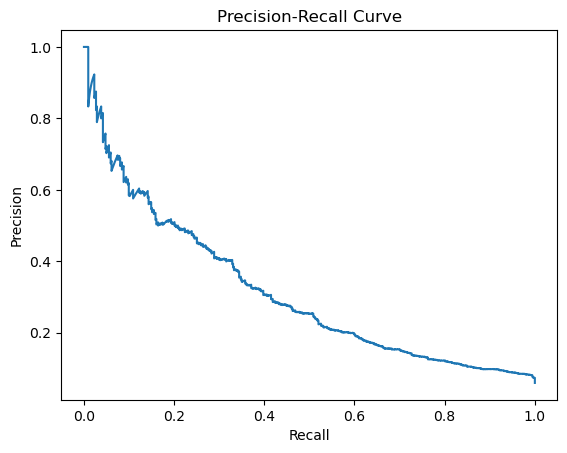

In [148]:
plt.plot(recalls, precisions)
plt.xlabel("Recall")
plt.ylabel("Precision")
plt.title("Precision-Recall Curve")


We see that the sharp dip near 0.0 observed in the earlier model has disappeared.

In [149]:
precisions

array([0.05954007, 0.05954685, 0.05955363, ..., 1.        , 1.        ,
       1.        ], shape=(8768,))

In [150]:
idx = np.where(recalls>=0.80)[0][-1]
print(f"Precision at 80 percent recalls:{precisions[idx]}")

Precision at 80 percent recalls:0.12230005837711617


Best f1 score: 0.36248682819077527 at threshold: 0.5422909259796143 


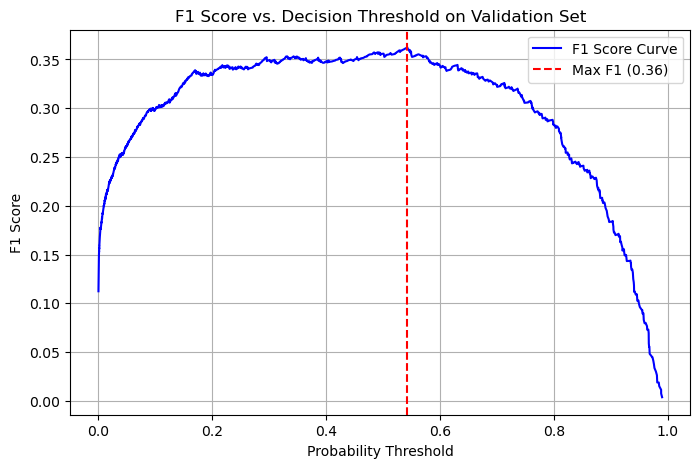

In [151]:
f1_scores = 2*(precisions)*(recalls)/(precisions + recalls + 1e-10)

best_idx = np.argmax(f1_scores)
best_threshold = thresholds[best_idx] if best_idx < len(thresholds) else 1.0
best_f1_score = f1_scores[best_idx]

print(f"Best f1 score: {best_f1_score} at threshold: {best_threshold} ")



plt.figure(figsize=(8, 5))
plt.plot(thresholds, f1_scores[:-1], label='F1 Score Curve', color='blue')
plt.axvline(best_threshold, color='red', linestyle='--', label=f'Max F1 ({best_f1_score:.2f})')
plt.xlabel('Probability Threshold')
plt.ylabel('F1 Score')
plt.title('F1 Score vs. Decision Threshold on Validation Set')
plt.legend()
plt.grid(True)
plt.show()

In [152]:
result = permutation_importance(model,X_valid,y_valid,n_repeats=10,random_state=42,scoring="average_precision"  )

perm_importance = pd.DataFrame({
    "feature": X_valid.columns,
    "importance_mean": result.importances_mean,
    "importance_std": result.importances_std
})

perm_importance = perm_importance.sort_values(
    by="importance_mean",
    ascending=False
)

print(perm_importance.head(28))

                   feature  importance_mean  importance_std
1              Day_of_week         0.136464        0.007838
6         Photovolt_lag_24         0.117028        0.008495
0                     Hour         0.093870        0.008478
8        Fossil_gas_lag_24         0.048114        0.006685
2                    Month         0.046593        0.011390
11      Price_rolling_mean         0.033400        0.009326
5     Wind_offshore_lag_24         0.029705        0.002508
3           Biomass_lag_24         0.021441        0.002926
12        Other_ren_lag_24         0.020730        0.009687
7           Lignite_lag_24         0.012516        0.006067
9   Hydro_pump_stor_lag_24         0.010258        0.004833
4             Hydro_lag_24         0.004390        0.003435
10       Other_conv_lag_24        -0.003744        0.004848


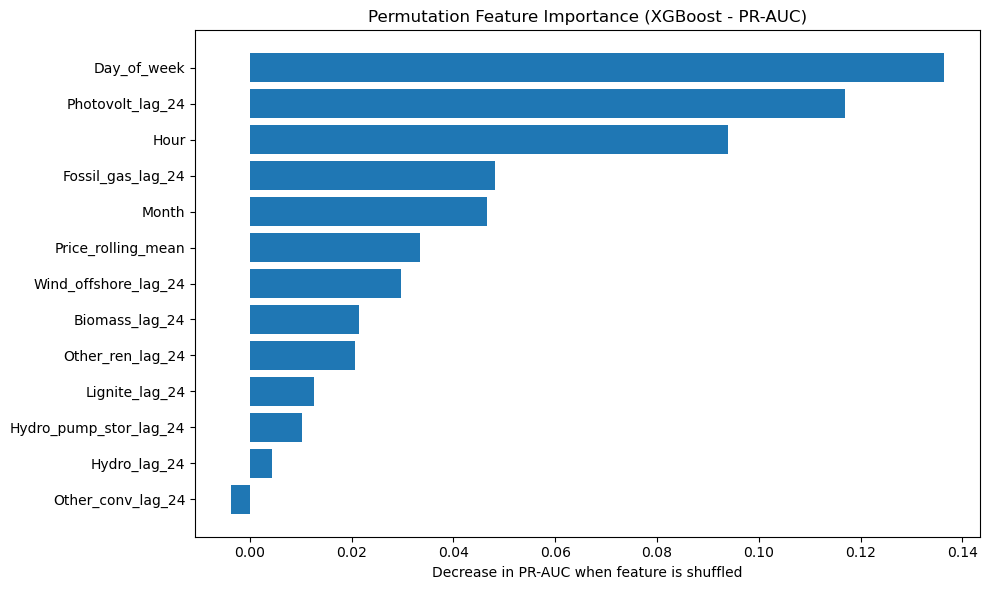

In [153]:
top_n = 15
top_features = perm_importance.head(top_n).iloc[::-1]

plt.figure(figsize=(10,6))
plt.barh(
    top_features["feature"],
    top_features["importance_mean"]
)

plt.xlabel("Decrease in PR-AUC when feature is shuffled")
plt.title("Permutation Feature Importance (XGBoost - PR-AUC)")
plt.tight_layout()
plt.show()

In [155]:
class_prev_valid = y_valid.sum()/len(y_valid)


valid_naive_f1 = 2 * (1) * (class_prev_valid) / (1 + class_prev_valid) 


print(f"Class prevalence in validation set : {class_prev_valid}")
print(f"Naive F1 baseline :{valid_naive_f1}")

Class prevalence in validation set : 0.05954007285974499
Naive F1 baseline :0.11238852476630493
